In [6]:
import os

SCALE, INTERVAL = 0.11, 4

mypass = '/mnt/ssd_data/Sasaki/MTSingleBeads'
mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

path0 = os.path.join(mypass,"20260121/beads_trans_crop_crop/beads_tracks.csv")
path1 = os.path.join(mypass,"20260121/exp_crop1/beads_tracks.csv")
path2 = os.path.join(mypass,"20260122/exp/beads_tracks.csv")
path3 = os.path.join(mypass,"20260122/exp001/beads_tracks.csv")
path4 = os.path.join(mypass,"20260122/exp002/beads_tracks.csv")

In [4]:
import pandas as pd

df = pd.read_csv(path3)

def calculate_skewness_over_lags(df, max_lag, scale = 0.11, interval = 1):
    results = []
    
    # 1. データのソート（粒子ごと・フレーム順）
    df = df.sort_values(['particle', 'frame'])
    
    for lag in range(1, max_lag + 1):
        # 粒子ごとに指定したラグでの変位を計算
        # diff(lag) は x[t+lag] - x[t] 相当の差分を計算
        dx_lag = df.groupby('particle')['x'].transform(lambda x: x.diff(periods=lag)) * scale
        dy_lag = df.groupby('particle')['y'].transform(lambda x: x.diff(periods=lag)) * scale
        
        # このラグにおける粒子ごとの歪度を計算
        # temp_df を作って計算するとスムーズです
        temp_df = pd.DataFrame({'particle': df['particle'], 'dx': dx_lag, 'dy': dy_lag})
        skew_per_particle = temp_df.groupby('particle').skew()
        
        # 粒子全体の平均（Time-Ensemble Average）を算出
        mean_skew = skew_per_particle.mean()
        
        results.append({
            'lag': lag * interval,
            'skew_x': mean_skew['dx'],
            'skew_y': mean_skew['dy']
        })
    
    return pd.DataFrame(results)

# --- 実行 ---
# 例：ラグ1から20まで計算
max_lag = 250
skew_df = calculate_skewness_over_lags(df, max_lag, SCALE, INTERVAL)

print(skew_df)

      lag    skew_x    skew_y
0       4  0.764176 -0.243707
1       8  0.920636 -0.491385
2      12  0.910640 -0.698304
3      16  0.904019 -0.857481
4      20  0.899411 -0.993781
..    ...       ...       ...
245   984  0.179741  0.096134
246   988  0.181804  0.084294
247   992  0.222552  0.077297
248   996  0.343037  0.077997
249  1000  0.343722  0.079839

[250 rows x 3 columns]


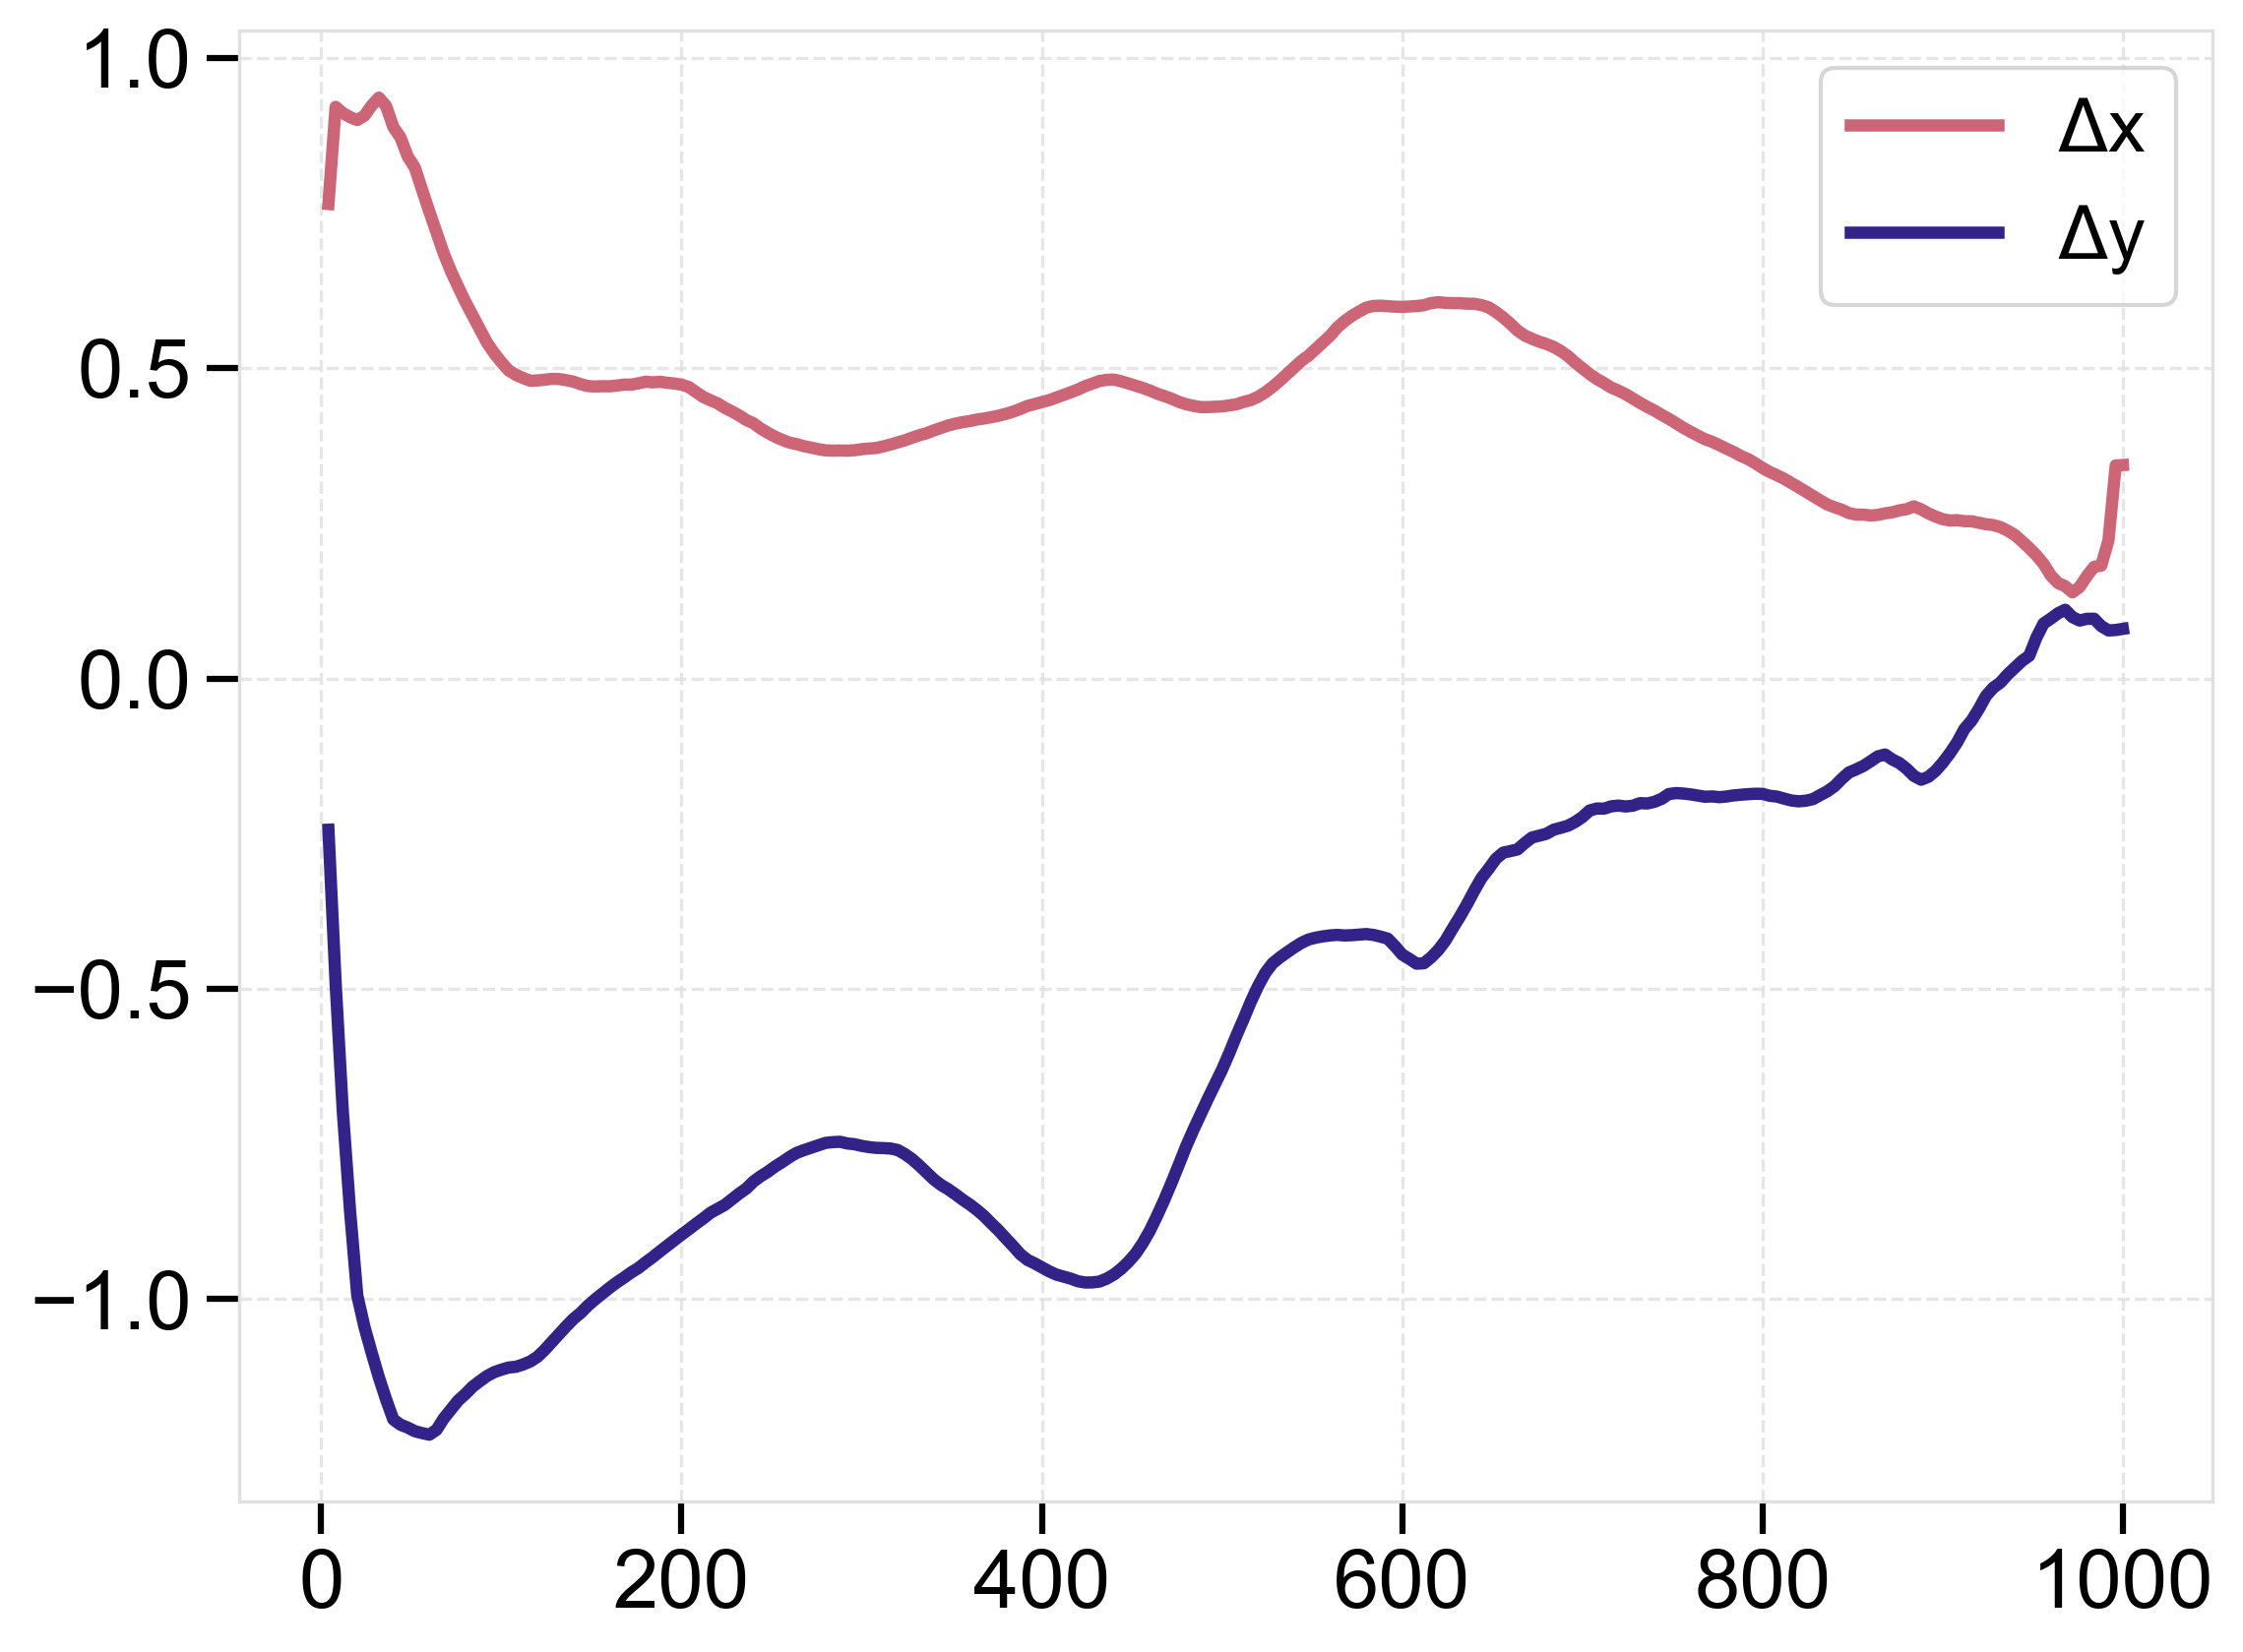

In [5]:
import matplotlib.pyplot as plt
plt.style.use('../libs/my_style.mplstyle')

fig, ax = plt.subplots()

ax.plot(skew_df['lag'], skew_df['skew_x'], label = "$\\Delta$x")
ax.plot(skew_df['lag'], skew_df['skew_y'], label = "$\\Delta$y")

ax.legend()

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv(path3)

import numpy as np
import pandas as pd

def calcMRL(df, max_lag, interval=1):
    results = []
    
    # 1. データのソート（粒子ごと・フレーム順）
    df = df.sort_values(['particle', 'frame'])
    
    for lag in range(1, max_lag + 1):
        # 粒子ごとに指定したラグでの変位を計算
        # groupごとにdiffをとることで、別の粒子との差分が混ざるのを防ぐ
        g = df.groupby('particle')
        dx = g['x'].diff(periods=lag)
        dy = g['y'].diff(periods=lag)

        # 移動距離 (dr) を計算
        dr = np.sqrt(dx**2 + dy**2)
        
        # 0除算を防ぐため、移動があるデータのみ抽出
        # (移動がない点は方向が定義できないため除外)
        mask = dr > 0
        temp_df = pd.DataFrame({
            'particle': df.loc[mask, 'particle'],
            'du': dx[mask] / dr[mask], # 単位ベクトルのx成分 (cosθ)
            'dv': dy[mask] / dr[mask]  # 単位ベクトルのy成分 (sinθ)
        })

        if temp_df.empty:
            results.append({'lag': lag * interval, 'mrl': np.nan})
            continue

        # --- 2. 粒子ごとの MRL を計算 ---
        # 各粒子の単位ベクトルを平均し、その合成ベクトルの長さを出す
        particle_stats = temp_df.groupby('particle').agg(['mean'])
        C = particle_stats['du']['mean']
        S = particle_stats['dv']['mean']
        
        # 粒子ごとの MRL: 1に近いほどその粒子は「真っ直ぐ」動いている
        mrl_per_particle = np.sqrt(C**2 + S**2) 
        
        # --- 3. 全粒子の平均 MRL を算出 ---
        # 全粒子の平均的な「指向性の強さ」
        mean_mrl = mrl_per_particle.mean()
        std_mrl = mrl_per_particle.std()
        
        results.append({
            'lag': lag * interval,
            'mrl': mean_mrl,
            'std':std_mrl
        })
    
    return pd.DataFrame(results)

# --- 実行 ---
# 例：ラグ1から20まで計算
max_lag = 250
mrl = calcMRL(df, max_lag, INTERVAL)

print(mrl)

      lag       mrl       std
0       4  0.080972  0.058772
1       8  0.107952  0.075346
2      12  0.122246  0.084033
3      16  0.139407  0.096597
4      20  0.145722  0.102246
..    ...       ...       ...
245   984  0.851939  0.195046
246   988  0.860764  0.196617
247   992  0.868554  0.201031
248   996  0.873854  0.204180
249  1000  0.878050  0.203833

[250 rows x 3 columns]


[(0.0, 1000.0),
 (0.0, 1.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta$ t [s]'),
 Text(0, 0.5, 'MRL')]

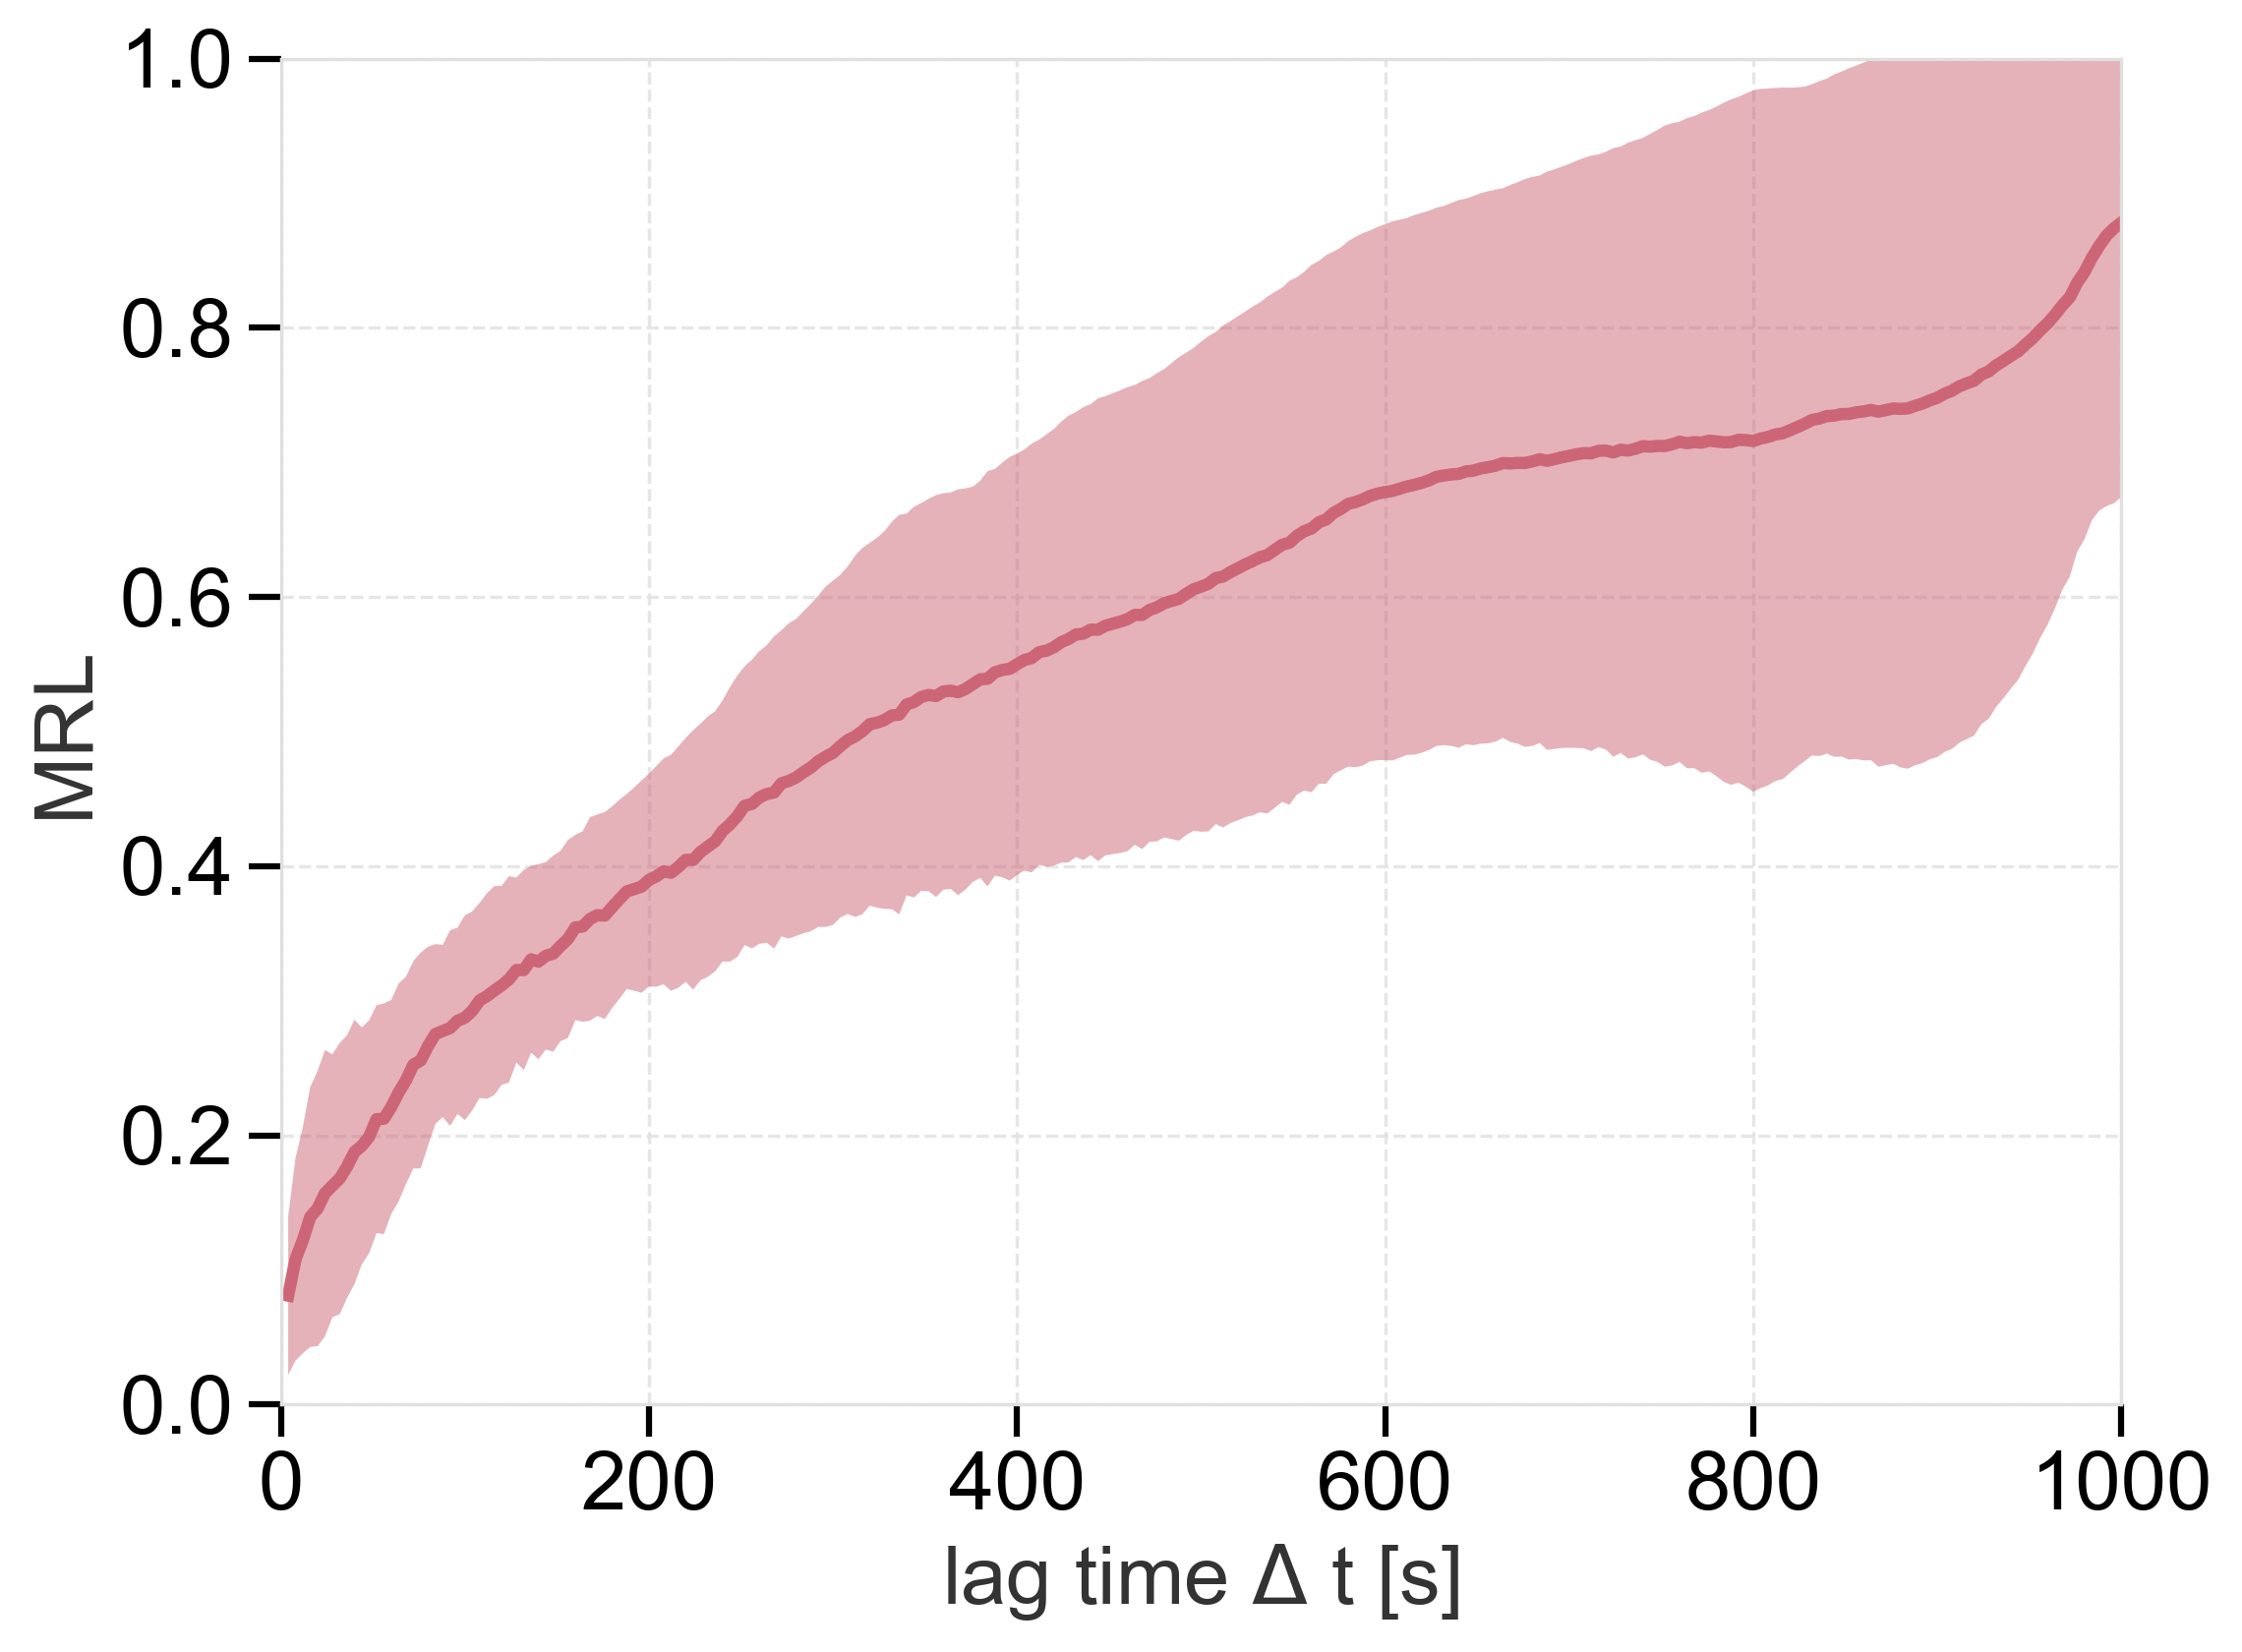

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(mrl['lag'], mrl['mrl'])
ax.fill_between(mrl['lag'], mrl['mrl'] + mrl['std'], mrl['mrl'] - mrl['std'], alpha = 0.5)

ax.set(
    xlim=(0, 1000),
    ylim=(0, 1),
    xscale='linear',
    yscale='linear',
    xlabel='lag time $\Delta$ t [s]',
    ylabel='MRL'
    )